In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
import pandas as pd
import scipy.signal as sig
import scipy.ndimage as ndi
import stackview as st
import networkx as nx
import matplotlib.pyplot as plt
import skimage as ski
import iplotx as ipx

from copy import copy
from tifffile import imread

from pyfibre.fibers.metrics import fibre_network_metrics
from pyfibre.fibers.metrics import fibre_metrics
from pyfibre.fibers.network_extraction import fibre_network_assignment
from pyfibre.fibers.analysis import network_analysis
from pyfibre.fibers.fibre_network import FibreNetwork

In [2]:
example_dir = "/home/vpc/Pictures/Exemplo_Picro/"
example_output_dir = os.path.join(example_dir, 'Saída')

os.makedirs(example_output_dir, exist_ok=True)

In [3]:
stack_path = os.path.join(example_dir, 'stack.tif')

stack = imread(stack_path)

nonpol = stack[4]
pol= stack[5]

st.blend(nonpol, pol)

[[0.65313061 0.675041   0.68044858 ... 0.80406351 0.79373252 0.77846167]
 [0.67163048 0.69114265 0.69523996 ... 0.81916779 0.80839341 0.79304529]
 [0.68382367 0.70009393 0.70131352 ... 0.82954321 0.8183197  0.80290141]
 ...
 [0.66418311 0.68533395 0.7089802  ... 0.38675914 0.33094558 0.31321208]
 [0.66299083 0.68043758 0.69908096 ... 0.3843516  0.32782702 0.30857931]
 [0.65634406 0.67159539 0.68612576 ... 0.38360294 0.32635645 0.30561274]]
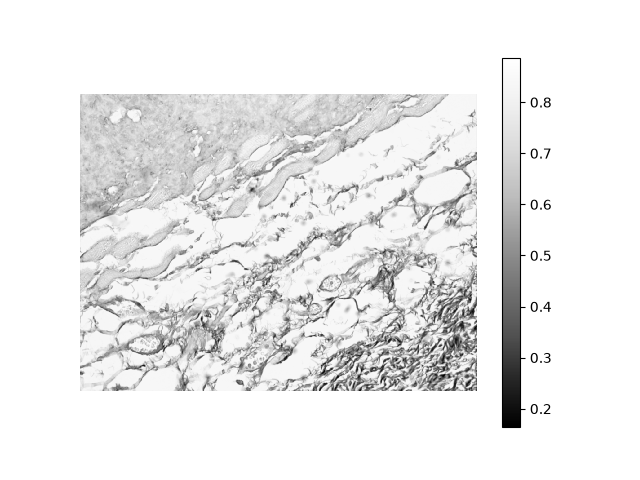
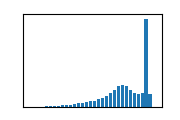

In [4]:
nonpol_gray = ski.color.rgb2gray(nonpol)
nonpol_gray = ski.transform.rescale(nonpol_gray, 0.5, mode='constant', anti_aliasing=None)
nonpol_gray = ndi.gaussian_filter(nonpol_gray, sigma=1)
st.insight(nonpol_gray)

/home/vpc/.local/share/miniforge3/envs/fib/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3748: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


[[3.48852529 3.66387373 3.78175366 ... 2.44268029 2.46647323 2.47450499]
 [3.56324742 3.79419585 3.89430422 ... 2.39529548 2.42916241 2.5422318 ]
 [3.66257327 3.94929324 3.99907957 ... 2.39574194 2.56318574 2.55720677]
 ...
 [4.05146215 4.28627522 4.48836744 ... 5.11856294 4.90848191 4.53049306]
 [3.89758704 4.24972972 4.396854   ... 4.86197028 4.60770573 4.30049752]
 [3.67140558 4.06678421 4.29465347 ... 4.57243125 4.38936486 3.9979527 ]]
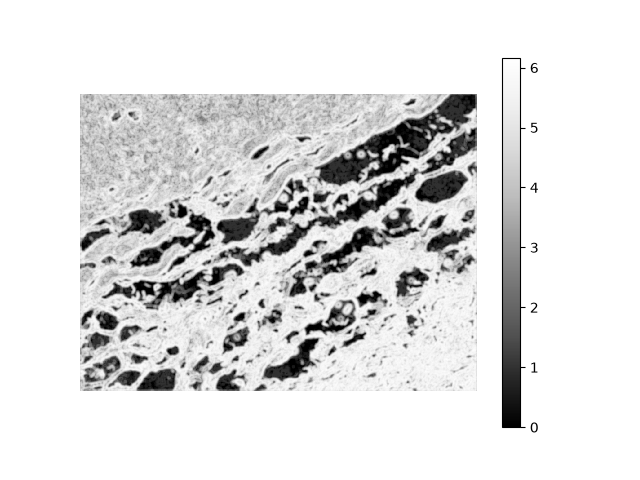
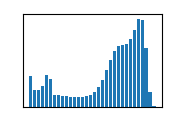

In [37]:
nonpol_ent = ski.filters.rank.entropy(
    nonpol_gray,
    ski.morphology.disk(5)
)
st.insight(nonpol_ent)

In [39]:
ent_count, ent_bins = np.histogram(nonpol_ent, 32)
ent_bins = ent_bins[1:]

min_idx = sig.argrelextrema(ent_count, np.less)
min_idx = np.array(*min_idx)

peak_idx, peak_props = sig.find_peaks(
    ent_count, prominence=0.1, distance=15)

min_x, min_y = [], []
for idx in min_idx:
    x = ent_bins[idx]
    y = ent_count[idx]

    min_x.append(x)
    min_y.append(y)

peak_x, peak_y = [], []
for idx in peak_idx:
    x = ent_bins[idx]
    y = ent_count[idx]

    peak_x.append(x)
    peak_y.append(y)


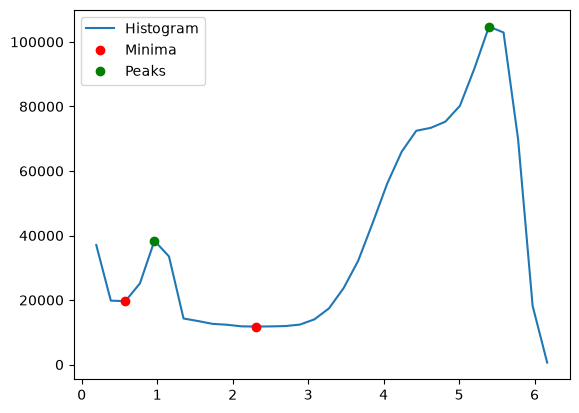

In [41]:
plt.plot(ent_bins, ent_count)
plt.plot(min_x, min_y, 'ro')
plt.plot(peak_x, peak_y, 'go')

plt.legend(['Histogram', 'Minima', 'Peaks'])
plt.show()
plt.close()

In [56]:
n_min, n_peak = len(min_idx), len(peak_idx)

low_ent, high_ent = [
    ski.measure.shannon_entropy(nonpol, base=i)
    for i in [32, 4]
    ]

for i in range(n_min):
    temp_thresh = min_x[i]
    if temp_thresh > low_ent and temp_thresh < high_ent:
        thresh_local = temp_thresh

In [59]:
tissue_mask = np.invert(nonpol_ent < thresh_local)
struc = ndi.generate_binary_structure(2,1)
tissue_mask = ndi.binary_erosion(
    tissue_mask,
    structure=ndi.iterate_structure(struc, 2)
)
tissue_mask = ndi.binary_fill_holes(tissue_mask)

st.curtain(tissue_mask, nonpol_gray)

In [10]:
from pyfibre.tools.filters import tubeness, hysteresis
from pyfibre.utilities import clear_border
from pyfibre.tools.preprocessing import clip_intensities, nl_means

In [6]:
pol_hsv = ski.color.rgb2hsv(pol)
pol_val = pol_hsv[..., 2]

pol_norm = clip_intensities(pol_val)
pol_eq = ski.exposure.equalize_adapthist(
    ski.exposure.rescale_intensity(pol_norm)
)
pol_val_dn = nl_means(pol_eq)

In [7]:
h_orig = pol_hsv[..., 0]
h = ndi.gaussian_filter(h_orig, sigma=2)
h = ski.util.invert(h)

p1 = 50
p2 = 100

h_ = ski.exposure.rescale_intensity(
    clip_intensities(h, p_intensity=(p1, p2))
)

h_ = h_ > ski.filters.threshold_otsu(h_)
h_ = ski.morphology.remove_small_objects(h_)

In [ ]:
sigma=1
scale=0.5

pol_fire = pol_val_dn * h_
print(pol_fire.shape)

pol_r = ski.transform.rescale(
    pol_fire,
    scale, mode='constant', anti_aliasing=None)
sigma *= scale

pol_tb = tubeness(pol_r)
thresh = hysteresis(pol_tb, alpha=0.5)
thresh = ski.morphology.remove_small_objects(
    thresh, max_size=32
)
distance = ndi.distance_transform_edt(
    thresh
)
smoothed_distance = ndi.gaussian_filter(
    distance, sigma=1
)

cleared_smoothed = clear_border(smoothed_distance)

In [76]:
maxima = ski.morphology.local_maxima(
    cleared_smoothed,
    allow_borders=True,
    indices=True
)

maxima_big = ski.morphology.local_maxima(
    cleared_smoothed,
    connectivity=100,
    allow_borders=True,
    indices=True
)
# same shit

In [141]:
peak_coords = ski.feature.peak_local_max(
    cleared_smoothed,
    labels=thresh,
    footprint=np.ones((10,10))
)

In [221]:
nuc_graph = nx.Graph()

pos = {}

for idx, coord in enumerate(peak_coords):
    coords = np.array([
        coord[1], coord[0]
    ])
    pos[idx] = coords
    nuc_graph.add_node(idx, pos=coords, index=idx)

nuc_graph.nodes(data=True)

NodeDataView({0: {'pos': array([1043,  782]), 'index': 0}, 1: {'pos': array([1144,  958]), 'index': 1}, 2: {'pos': array([666, 763]), 'index': 2}, 3: {'pos': array([1258,  708]), 'index': 3}, 4: {'pos': array([1034,  958]), 'index': 4}, 5: {'pos': array([1214,  923]), 'index': 5}, 6: {'pos': array([1027,  794]), 'index': 6}, 7: {'pos': array([773, 907]), 'index': 7}, 8: {'pos': array([549, 790]), 'index': 8}, 9: {'pos': array([432, 958]), 'index': 9}, 10: {'pos': array([1278,  740]), 'index': 10}, 11: {'pos': array([849, 368]), 'index': 11}, 12: {'pos': array([1255,  671]), 'index': 12}, 13: {'pos': array([1278,  601]), 'index': 13}, 14: {'pos': array([1020,  789]), 'index': 14}, 15: {'pos': array([732, 958]), 'index': 15}, 16: {'pos': array([1175,  845]), 'index': 16}, 17: {'pos': array([623, 773]), 'index': 17}, 18: {'pos': array([1246,  818]), 'index': 18}, 19: {'pos': array([1194,  806]), 'index': 19}, 20: {'pos': array([1186,  893]), 'index': 20}, 21: {'pos': array([365, 958]), 'i

In [222]:
nx.apply_matplotlib_colors(
    nuc_graph, "index", "color", plt.colormaps.get_cmap('prism')
)

nuc_graph.nodes(data=True)

NodeDataView({0: {'pos': array([1043,  782]), 'index': 0, 'color': (1.0, 0.0, -0.0, 1.0)}, 1: {'pos': array([1144,  958]), 'index': 1, 'color': (1.0, 0.0, -0.0, 1.0)}, 2: {'pos': array([666, 763]), 'index': 2, 'color': (1.0, 0.0, -0.0, 1.0)}, 3: {'pos': array([1258,  708]), 'index': 3, 'color': (1.0, 0.0, -0.0, 1.0)}, 4: {'pos': array([1034,  958]), 'index': 4, 'color': (1.0, 0.0, -0.0, 1.0)}, 5: {'pos': array([1214,  923]), 'index': 5, 'color': (1.0, 0.0, -0.0, 1.0)}, 6: {'pos': array([1027,  794]), 'index': 6, 'color': (1.0, 0.0, -0.0, 1.0)}, 7: {'pos': array([773, 907]), 'index': 7, 'color': (1.0, 0.0, -0.0, 1.0)}, 8: {'pos': array([549, 790]), 'index': 8, 'color': (1.0, 0.0, 0.0, 1.0)}, 9: {'pos': array([432, 958]), 'index': 9, 'color': (1.0, 0.0, 0.0, 1.0)}, 10: {'pos': array([1278,  740]), 'index': 10, 'color': (1.0, 0.0, 0.0, 1.0)}, 11: {'pos': array([849, 368]), 'index': 11, 'color': (1.0, 0.0, 0.0, 1.0)}, 12: {'pos': array([1255,  671]), 'index': 12, 'color': (1.0, 0.0, 0.0, 1

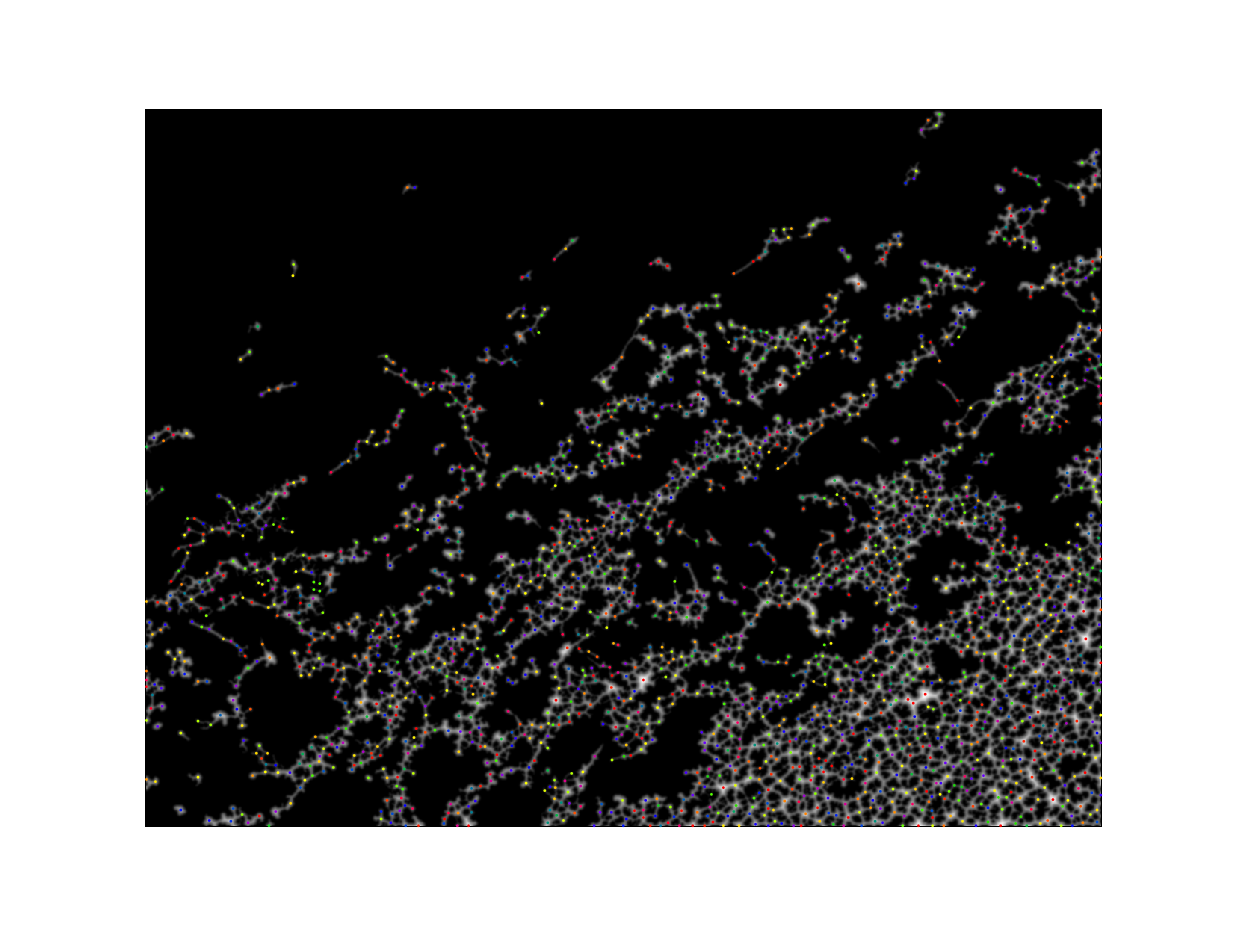

In [249]:
f, a = plt.subplots()
st.imshow(cleared_smoothed, axes=a, continue_drawing=True)
style = {"vertex": {
    "facecolor": nuc_graph.nodes.data("color"),
    "size": 1
    }
}
ipx.network(nuc_graph,
layout=pos, style=style,
ax=a
)

f.set_dpi(200)
f.tight_layout()

In [251]:
np.arange(1996)

array([   0,    1,    2, ..., 1993, 1994, 1995], shape=(1996,))

In [ ]:


st.switch([
    pol_val_dn,
    pol_fire,
    pol_tb,
    thresh,
    distance,
    smoothed_distance,
    cleared_smoothed
    ])

# the artifact already shows here.

In [ ]:
opt_params = {
    "scale": 0.5,
    "angle_thresh": 70,
    "r_thresh": 50,
    "nuc_radius": 20,
    "nuc_thresh": 10,
    "lmp_thresh": 0.5,
    "sigma": 1
}

In [72]:
cleared, network = network_analysis(pol_fire, return_img=True, **opt_params)

In [113]:
networks = fibre_network_assignment(network)

good_nets = []
fibers = []

for netw in networks:
    subg = netw.graph
    fibs = netw.generate_fibres()

    if len(fibs) < 3:
        continue
    
    for fib in fibs:
        fibers.append(fib)

    good_nets.append(netw)


In [114]:
len(fibers), len(good_nets)

(1991, 98)

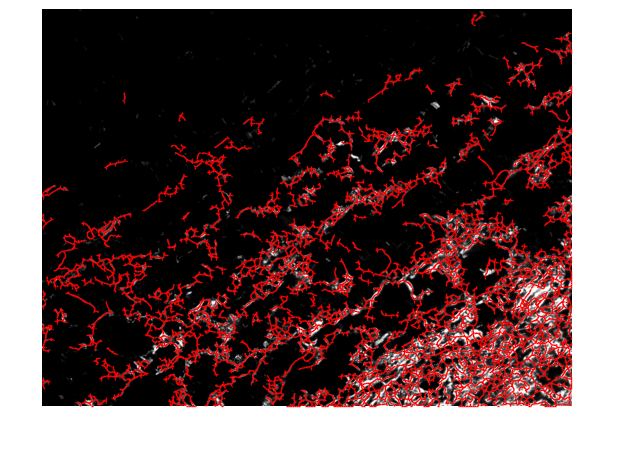

In [121]:
pol_thresh = ski.filters.threshold_otsu(pol_fire)
pol_masked = pol_fire > pol_thresh
pol_masked = ski.morphology.remove_small_objects(pol_masked)
pol_masked = ski.morphology.opening(pol_masked)

In [217]:
len(good_nets)

98

In [ ]:
from scipy.ndimage.filters import gaussian_filter
from scipy.ndimage.morphology import binary_dilation
from skimage import draw
from skimage.morphology import remove_small_holes

from pyfibre.tools.convertors import binary_to_regions
from pyfibre.fibers.fibre_utilities import get_node_coord_array


def draw_network(network, label_image, index=1):
    nodes_coord = get_node_coord_array(network)
    label_image[nodes_coord[:, 0], nodes_coord[:, 1]] = index

    for edge in list(network.edges):
        start = list(network.nodes[edge[1]]["xy"])
        end = list(network.nodes[edge[0]]["xy"])
        line = draw.line(*(start + end))
        label_image[line] = index

    return label_image

def networks_to_binary(networks, shape, area_threshold=200, iterations=9, sigma=None):
    """Return a global binary representing areas of an image
    containing networks"""

    binary = np.zeros(shape, dtype=int)

    # Create skeleton image based on connected components in network
    for index, network in enumerate(networks):
        draw_network(network.graph, binary, index=1)

    # Dilate skeleton image
    if iterations > 0:
        binary = binary_dilation(binary, iterations=iterations)

    # Smooth dilated image
    if sigma is not None:
        smoothed = gaussian_filter(binary.astype(float), sigma=sigma)
        # Convert float image back to binary
        binary = np.where(smoothed, 1, 0)

    # Remove smooth holes with area less than threshold
    binary = remove_small_holes(
        binary.astype(bool),
        max_size=area_threshold)

    return binary.astype(int)


/tmp/ipykernel_98987/2427729318.py:1: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter
/tmp/ipykernel_98987/2427729318.py:2: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_dilation


In [ ]:
def region_check(region, min_size=0, min_frac=0, edges=False, max_x=0, max_y=0):
    """Return whether input region passes minimum area and average
    intensity checks"""

    check = True

    if edges:
        minr, minc, maxr, maxc = region.bbox
        edge_check = (minr != 0) * (minc != 0)
        edge_check *= maxr != max_x
        edge_check *= maxc != max_y

        check *= edge_check

    check *= region.filled_area >= min_size

    if region._intensity_image is not None:
        region_filter = region.image * region.intensity_image
        region_frac = region_filter.sum() / region.filled_area
        check *= region_frac >= min_frac

    return check

In [ ]:
def sort_by_area(segments):
    """Sort a list of skimage regionprops segments by
    thier filled_area attribute"""

    areas = [segment.filled_area for segment in segments]
    indices = np.argsort(areas)[::-1]
    sorted_segments = [segments[i] for i in indices]

    return sorted_segments

def binary_to_regions(binary, intensity_image=None, min_size=0, min_frac=0.0):
    """Convert a binary mask image to a set of scikit-image
    segment objects"""

    if binary.ndim > 2:
        binary = binary.sum(axis=0)

    labels = ski.measure.label(binary.astype(np.uint32))

    regions = [
        region
        for region in ski.measure.regionprops(
            labels,
            intensity_image=intensity_image
            )
        if region_check(region, min_size, min_frac)
    ]

    regions = sort_by_area(regions)

    return labels, regions

In [186]:
binary = networks_to_binary(
    good_nets,
    pol_fire.shape,
    iterations=3,
    area_threshold=10
    )

pol_labels, pol_regions = binary_to_regions(binary, pol_fire)

/tmp/ipykernel_98987/1912184384.py:15: FutureWarning: `RegionProperties.filled_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_filled` instead. 
  check *= region.filled_area >= min_size
/tmp/ipykernel_98987/1912184384.py:18: FutureWarning: `RegionProperties.intensity_image` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.image_intensity` instead. 
  region_filter = region.image * region.intensity_image
/tmp/ipykernel_98987/1912184384.py:19: FutureWarning: `RegionProperties.filled_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_filled` instead. 
  region_frac = region_filter.sum() / region.filled_area
/tmp/ipykernel_98987/1912184384.py:28: FutureWarning: `RegionProperties.filled_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_filled` instead. 
  areas = [segmen

In [187]:
len(ski.measure.regionprops(pol_labels))

81

In [188]:
len(pol_regions), len(pol_labels), len(good_nets), len(fibs)

(81, 1920, 98, 790)

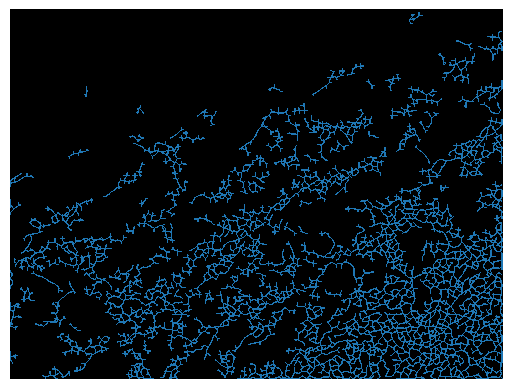

In [267]:
st.imshow(binary)

[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]
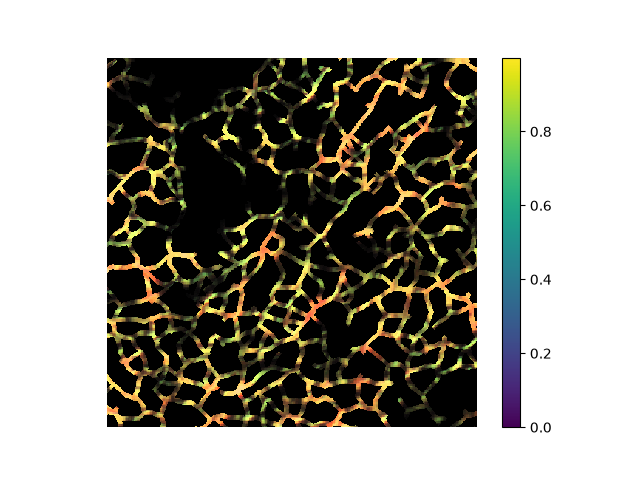
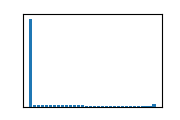

In [ ]:
masked_networks = ski.color.hsv2rgb(
        np.stack(
            [ ch * binary for ch in [ h_orig, pol_hsv[...,1], pol_fire ] ], axis=-1
        )
    )[1300:1800, 2000:2500]

st.imshow(masked_networks)

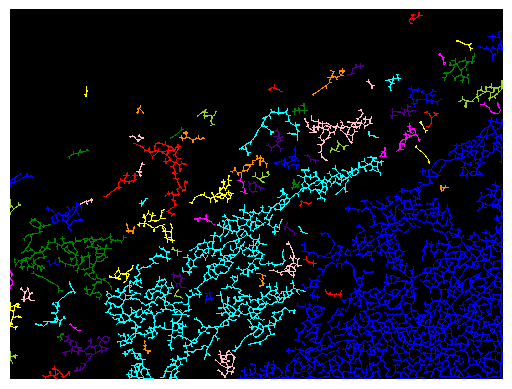

In [189]:
st.imshow(ski.color.label2rgb(pol_labels))

In [126]:
len(regions), len(good_nets)

(60, 98)

In [ ]:
def draw_network(network, label_image, index=1):
    nodes_coord = get_node_coord_array(network)
    label_image[nodes_coord[:, 0], nodes_coord[:, 1]] = index

    for edge in list(network.edges):
        start = list(network.nodes[edge[1]]["xy"])
        end = list(network.nodes[edge[0]]["xy"])
        line = draw.line(*(start + end))
        label_image[line] = index

    return label_image

def get_lines(network):
    for edge in list(network.edges):
        start = list(network.nodes[edge[1]]["xy"])
        end = list(network.nodes[edge[0]]["xy"])
        line = draw.line(*(start + end))

    return line 

#skeleton = np.zeros(pol_fire.shape, dtype=int)

fibs = []
node_coords = []

for network in good_nets:
    fibres = network.generate_fibres()
    
    for idx, fibre in enumerate(fibres):
        node_coord = [
            fibre.graph.nodes[node]['xy']
            for node in fibre.graph.nodes ]
        fibs.append(fibre)

In [ ]:
for node in fibs[100].graph.nodes:
    print(fibs[100].graph.nodes[node]['xy'])

[ 734 2132]
[ 730 2126]
[ 724 2118]
[ 714 2110]
[ 714 2104]


In [193]:
test_img = fibres_to_label_image(
    fibs,
    pol_gray.shape,
    iterations=5,
)

In [196]:
test_img

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 561, 561, 561],
       [  0,   0,   0, ..., 561, 561, 561],
       [  0,   0,   0, ..., 561, 561, 561]], shape=(1920, 2560))